In [11]:
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
import io

In [12]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name='KEV Enriched')
print(f"Loaded {len(df)} rows")

# Extract first-listed tactic per CVE
df['tactic'] = df['Tactic(s)'].fillna('Unknown').str.split('; ').str[0].str.strip()

# Only keep the 4 real tactic classes with enough data to learn from
valid_tactics = ['Initial Access', 'Defense Evasion', 'Execution', 'Credential Access']
df = df[df['tactic'].isin(valid_tactics)].copy()
print(f"Filtered to {len(df)} rows")
print(df['tactic'].value_counts())

Saving sample.xlsx to sample (2).xlsx
Loaded 1539 rows
Filtered to 974 rows
tactic
Initial Access       572
Defense Evasion      189
Execution            176
Credential Access     37
Name: count, dtype: int64


In [13]:
df['has_windows'] = df['Platform(s)'].astype(str).str.contains('Windows').astype(int)
df['has_linux']   = df['Platform(s)'].astype(str).str.contains('Linux').astype(int)
df['has_network'] = df['Platform(s)'].astype(str).str.contains('Network').astype(int)
df['has_cloud']   = df['Platform(s)'].astype(str).str.contains('SaaS|IaaS|Azure|Office 365').astype(int)
df['platform_count'] = df['Platform(s)'].astype(str).str.split(';').apply(len)

# CWE: extract type ID and one-hot encode top 20 most common
df['cwe'] = df['CWE(s)'].astype(str).str.extract(r'(CWE-\d+)')[0].fillna('Unknown')
top_cwes = df['cwe'].value_counts().nlargest(20).index
df['cwe_encoded'] = df['cwe'].where(df['cwe'].isin(top_cwes), other='Other')

# Year added and number of ATT&CK techniques mapped
df['year'] = pd.to_datetime(df['Date Added'], errors='coerce').dt.year.fillna(2022).astype(int)
df['technique_count'] = df['ATT&CK ID(s)'].fillna('').astype(str).apply(
    lambda x: len([t for t in x.split(';') if t.strip()]) if x else 0
)

# Assemble final feature matrix
cwe_dummies = pd.get_dummies(df['cwe_encoded'], prefix='cwe')
features = pd.concat([
    df[['has_windows','has_linux','has_network','has_cloud','platform_count','year','technique_count']],
    cwe_dummies
], axis=1)

# Encode tactic labels as integers
le = LabelEncoder()
labels = le.fit_transform(df['tactic'])

print(f"Feature matrix shape: {features.shape}")
for i, c in enumerate(le.classes_):
    print(f"  [{i}] {c}: {(df['tactic']==c).sum()} rows")

Feature matrix shape: (974, 28)
  [0] Credential Access: 37 rows
  [1] Defense Evasion: 189 rows
  [2] Execution: 176 rows
  [3] Initial Access: 572 rows


In [14]:
# Train the Random Forest (100 trees), run predictions, compare accuracy to Logistic Regression
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
baseline = dummy.score(X_test, y_test)
print(f"Majority class baseline: {baseline:.1%}")

# Random Forest doesn't need feature scaling — tree splits are rank-based, not distance-based
print(f"Training: {len(X_train)} | Test: {len(X_test)}")

Majority class baseline: 59.0%
Training: 779 | Test: 195


In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred)
acc_lr = 0.938  # paste from Notebook 2

print(f"Random Forest:        {acc_rf:.1%}")
print(f"Logistic Regression:  {acc_lr:.1%}")
print(f"Majority class floor: {baseline:.1%}")
print(f"\n{classification_report(y_test, y_pred, target_names=le.classes_)}")

Random Forest:        96.9%
Logistic Regression:  93.8%
Majority class floor: 59.0%

                   precision    recall  f1-score   support

Credential Access       1.00      1.00      1.00         7
  Defense Evasion       1.00      0.92      0.96        38
        Execution       0.97      0.91      0.94        35
   Initial Access       0.96      1.00      0.98       115

         accuracy                           0.97       195
        macro avg       0.98      0.96      0.97       195
     weighted avg       0.97      0.97      0.97       195



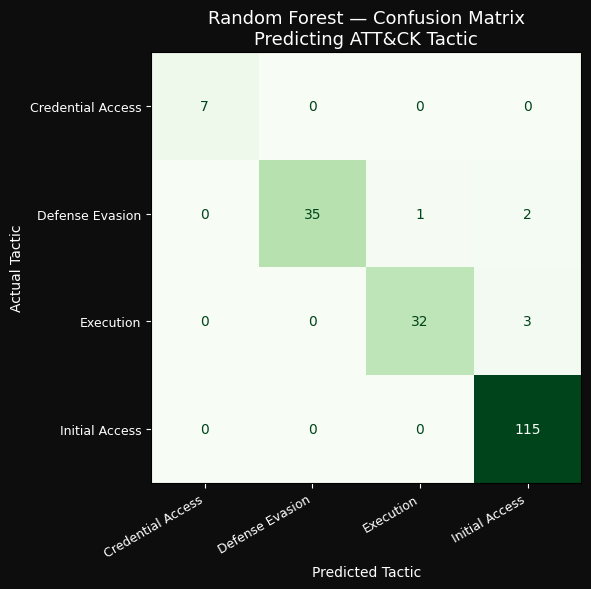

In [16]:
# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Random Forest — Confusion Matrix\nPredicting ATT&CK Tactic', color='white', fontsize=13)
ax.tick_params(colors='white', labelsize=9)
ax.set_xlabel('Predicted Tactic', color='white')
ax.set_ylabel('Actual Tactic', color='white')
plt.xticks(rotation=30, ha='right', color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.savefig('rf_confusion.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

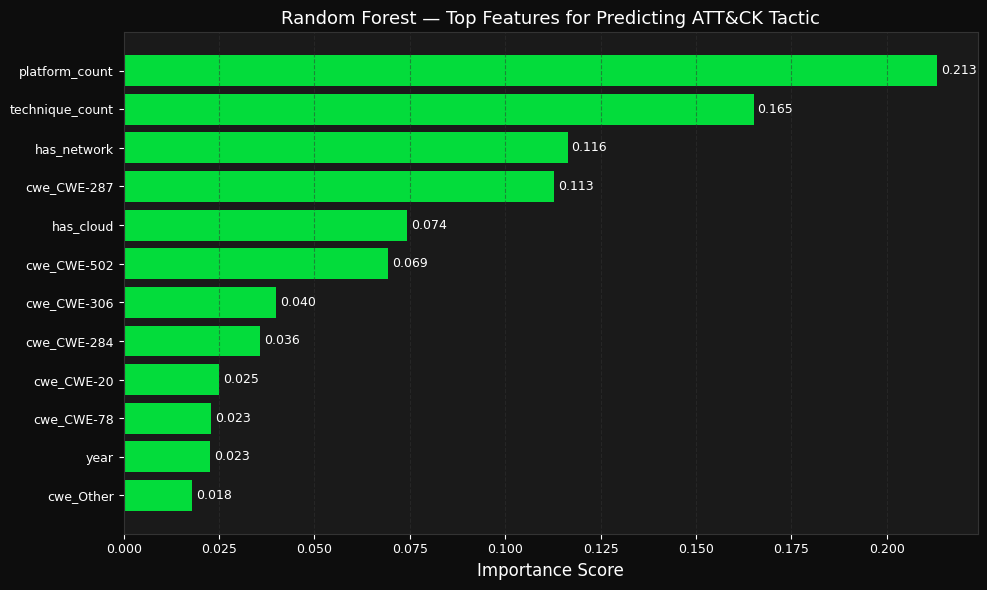

In [17]:
# Feature importance: shows which input variables the model relied on most to predict tactics
importances = pd.Series(rf_model.feature_importances_, index=features.columns)
top_features = importances.nlargest(12)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

bars = ax.barh(top_features.index[::-1], top_features.values[::-1], color='#00FF41', alpha=0.85)
ax.set_xlabel('Importance Score', color='white', fontsize=12)
ax.set_title('Random Forest — Top Features for Predicting ATT&CK Tactic', color='white', fontsize=13)
ax.tick_params(colors='white', labelsize=9)
for spine in ax.spines.values(): spine.set_color('#333333')
ax.xaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)

for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

In [18]:
# Save RF probability scores
proba = rf_model.predict_proba(X_test)
proba_df = pd.DataFrame(proba, columns=[f'prob_{t}' for t in le.classes_])
proba_df['actual_tactic'] = le.inverse_transform(y_test)
proba_df['predicted_tactic'] = le.inverse_transform(y_pred)
proba_df['correct'] = (y_test == y_pred)
proba_df.to_csv('rf_probabilities.csv', index=False)

print(f"=== NOTEBOOK 3 SUMMARY ===")
print(f"RF Accuracy: {acc_rf:.1%} | LR Accuracy: {acc_lr:.1%}")
print(f"Winner: {'Random Forest' if acc_rf > acc_lr else 'Logistic Regression' if acc_lr > acc_rf else 'Tie!'}")

=== NOTEBOOK 3 SUMMARY ===
RF Accuracy: 96.9% | LR Accuracy: 93.8%
Winner: Random Forest
